<a href="https://colab.research.google.com/github/Hemn-Khdr/Multi-Model-AI/blob/Hemn-Khdr-patch-1_pahse--1-project/Multi_model_A1_Phase_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
### 📦 1. Setup
import pandas as pd
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load file
file_path = '/content/drive/MyDrive/IEEE and comprehensive/HEMN.csv'
df = pd.read_csv(file_path)
print(df.head())

Mounted at /content/drive


/tmp/ipython-input-868927787.py:11: DtypeWarning: Columns (28,29,31,33,35,37,39,41,43,47,49,51,55,57,59,61,63,65,67,69,71,77,79,81,83,85,87,91,93,95,97,101,103,105,107,109,136,137,139,140,145,148,153,156,161,163,164,168,169,171,172) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


   Age_at_Exam     Sex    sBP    sBP_Date        BMI    BMI_Date   LDL  \
0           69    Male  140.0  2010-03-18  26.000000  2010-12-17  3.35   
1           56  Female  120.0  2011-11-03  24.000000  2011-11-03  4.01   
2           35  Female  100.0  2014-02-21  51.195667  2014-02-21  3.11   
3           43  Female  138.0  2013-07-04  67.794421  2013-07-04  2.96   
4           49    Male  141.0  2013-03-13  34.000000  2013-01-24  4.06   

     LDL_Date   HDL    HDL_Date  ...  duration_b_R1_[corticosteroid]_Days  \
0  2010-03-06  1.03  2010-03-06  ...                                  NaN   
1  2011-10-04  1.84  2011-10-04  ...                                  NaN   
2  2014-02-24  1.26  2014-02-24  ...                                  NaN   
3  2013-08-02  1.09  2013-08-02  ...                                  NaN   
4  2013-01-24  1.34  2013-01-24  ...                                  NaN   

  total_b_R1_[corticosteroid]_Records  first_b_R1_[1stlineantidiabetic]  \
0                

\

Raw df shape after basic filters: (234464, 175)

Patients eligible at landmark: 25869
Label distribution:
 y
0    25788
1       81
Name: count, dtype: int64

HTN diagnostics: among HTN==1 rows, HTN_OnsetDate missing rate = 0.000

CORE features present: ['Age_at_Exam', 'Sex', 'HTN_FW', 'AFib_FW', 'CAD_FW', 'sBP_Mean_FW', 'A1c_Mean_FW', 'LDL_Mean_FW', 'TG_Mean_FW', 'FBS_Mean_FW', 'BMI_Last_FW', 'CKD_FW']


,Patient_ID,y,Age_at_Exam,Sex,HTN_FW,AFib_FW,CAD_FW,sBP_Mean_FW,A1c_Mean_FW,LDL_Mean_FW,TG_Mean_FW,FBS_Mean_FW,BMI_Last_FW,CKD_FW
0,1001000000001150,0,58,Male,0,0,0,131.6,6.775,2.53,1.16,7.625,29.6,0
1,1001000000001343,0,66,Female,0,0,0,130.0,NaN,NaN,NaN,6.650,NaN,0
2,1001000000001950,0,72,Female,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
3,1001000000002046,0,62,Female,0,0,0,NaN,NaN,2.94,1.69,4.800,NaN,0
4,1001000000002528,0,49,Male,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0


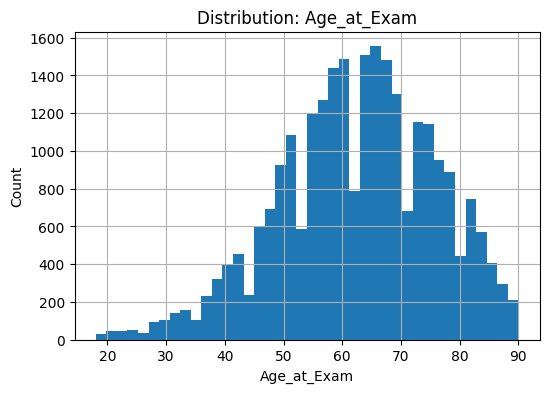

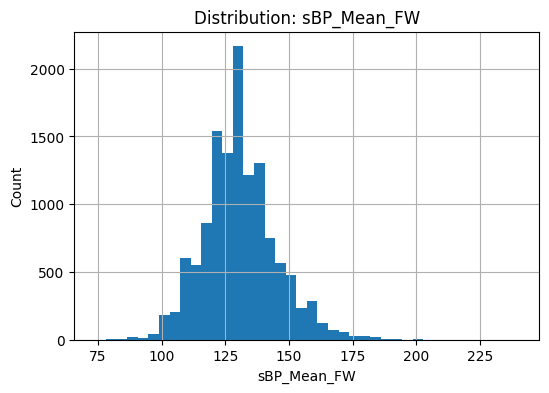

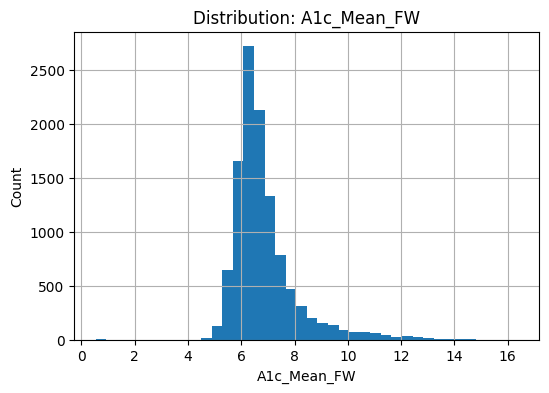

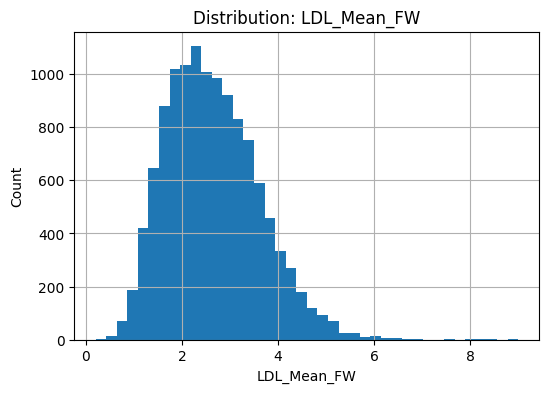

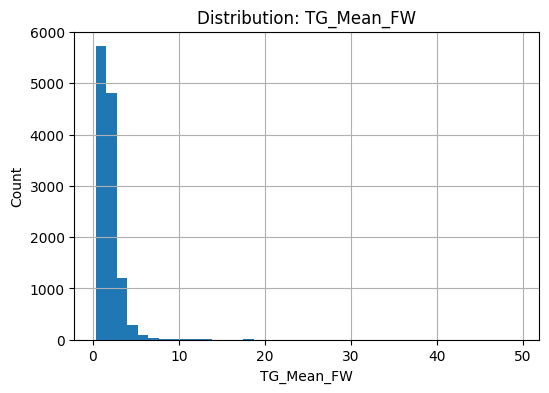

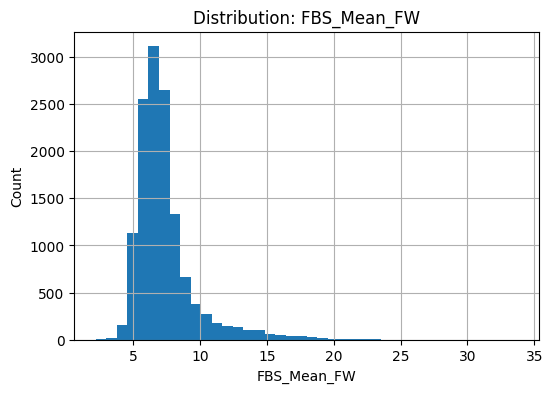

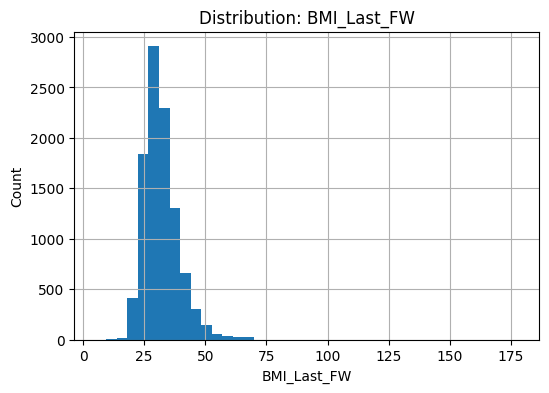


Missingness % (CORE features):


,0
BMI_Last_FW,61.10
A1c_Mean_FW,56.85
LDL_Mean_FW,53.29
TG_Mean_FW,52.80
sBP_Mean_FW,50.68
FBS_Mean_FW,48.90
Sex,0.00
Age_at_Exam,0.00
AFib_FW,0.00
HTN_FW,0.00


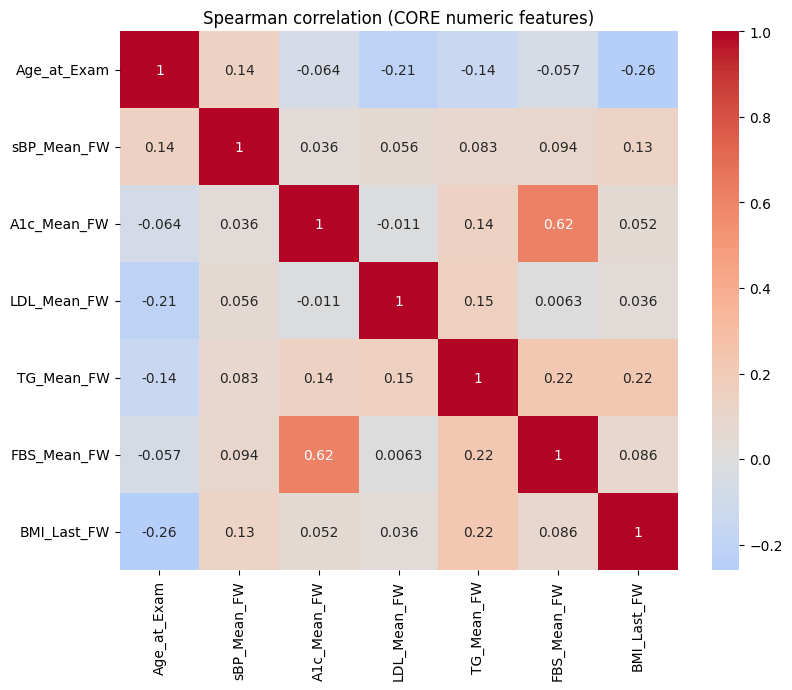

In [ ]:
# ============================================================
# Part 1 — Data prep + EDA (leakage-safe landmark cohort)
# (Corrected + robust version of your section)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================
FEATURE_WINDOW_MONTHS = 6
OUTCOME_HORIZON_YEARS = 5

ID_COL = "Patient_ID"
DM_COL = "DM_OnsetDate"
STROKE_DATE_COL = "[Stroke_Date]"
DEATH_DATE_COL  = "[Deceased_Date]"

CORE_FEATURES = [
    "Age_at_Exam", "Sex",
    "HTN_FW", "AFib_FW", "CAD_FW",
    "sBP_Mean_FW",
    "A1c_Mean_FW", "LDL_Mean_FW", "TG_Mean_FW", "FBS_Mean_FW",
    "BMI_Last_FW",
    "CKD_FW",
]

# ============================================================
# STEP 1 — Sanity checks
# ============================================================
for c in [ID_COL, DM_COL]:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

# Keep only diabetics if the column exists
if "Diabetes" in df.columns:
    df = df[df["Diabetes"] == 1].copy()

# ============================================================
# STEP 2 — Parse dates needed for CORE + outcome logic
# ============================================================
date_cols = [
    DM_COL, STROKE_DATE_COL, DEATH_DATE_COL,
    "sBP_Date", "BMI_Date",
    "LDL_Date", "A1c_Date", "TG_Date", "FBS_Date",
    "HTN_OnsetDate",
    "[AtrialFibrillation_Date]",
    "[CAD_Date]",
    "[CKD_Date]",
]
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Keep essential DM onset + ID
df = df[df[ID_COL].notna() & df[DM_COL].notna()].copy()
df = df.sort_values([ID_COL, DM_COL])

print("Raw df shape after basic filters:", df.shape)

# ============================================================
# STEP 3 — Patient-level timeline + leakage-safe label (NO ML)
# ============================================================
# Compute min dates per patient (stroke/death may not exist as columns)
agg_dict = {DM_COL: "min"}
if STROKE_DATE_COL in df.columns:
    agg_dict[STROKE_DATE_COL] = "min"
if DEATH_DATE_COL in df.columns:
    agg_dict[DEATH_DATE_COL] = "min"

patient = df.groupby(ID_COL, as_index=False).agg(agg_dict).rename(columns={
    DM_COL: "DM_OnsetDate",
    STROKE_DATE_COL: "Stroke_Date" if STROKE_DATE_COL in df.columns else STROKE_DATE_COL,
    DEATH_DATE_COL:  "Deceased_Date" if DEATH_DATE_COL in df.columns else DEATH_DATE_COL,
})

# Ensure columns exist even if absent in raw df
if "Stroke_Date" not in patient.columns:
    patient["Stroke_Date"] = pd.NaT
if "Deceased_Date" not in patient.columns:
    patient["Deceased_Date"] = pd.NaT

patient["Landmark_Date"] = patient["DM_OnsetDate"] + pd.DateOffset(months=FEATURE_WINDOW_MONTHS)
patient["Horizon_End"]   = patient["DM_OnsetDate"] + pd.DateOffset(years=OUTCOME_HORIZON_YEARS)

# Exclude patients not at risk at prediction time (stroke/death on/before landmark)
exclude_early_stroke = patient["Stroke_Date"].notna() & (patient["Stroke_Date"] <= patient["Landmark_Date"])
exclude_early_death  = patient["Deceased_Date"].notna() & (patient["Deceased_Date"] <= patient["Landmark_Date"])
patient = patient[~exclude_early_stroke & ~exclude_early_death].copy()

# Label: stroke AFTER landmark and within 5 years of DM onset
patient["y"] = (
    patient["Stroke_Date"].notna() &
    (patient["Stroke_Date"] > patient["Landmark_Date"]) &
    (patient["Stroke_Date"] <= patient["Horizon_End"])
).astype(int)

print("\nPatients eligible at landmark:", len(patient))
print("Label distribution:\n", patient["y"].value_counts(dropna=False))

# ============================================================
# STEP 4 — Merge row-level data for feature construction
# ============================================================
# Bring Landmark_Date + y to each raw row for window filtering; keep DM_OnsetDate from df only
df2 = df.merge(patient[[ID_COL, "Landmark_Date", "y"]], on=ID_COL, how="inner")
assert DM_COL in df2.columns, "DM_OnsetDate missing from df2 — merge logic is wrong."

def in_fw(date_series, start_series, end_series):
    """Feature window filter: DM_OnsetDate <= date <= Landmark_Date"""
    return date_series.notna() & (date_series >= start_series) & (date_series <= end_series)

# Start patient-level features table (one row per patient)
features_df = patient[[ID_COL, "DM_OnsetDate", "Landmark_Date", "Horizon_End", "y"]].copy()

# ============================================================
# STEP 5 — CORE feature engineering (NO extras)
# ============================================================

# ---- Demographics
if "Age_at_Exam" in df2.columns:
    df2["Age_at_Exam"] = pd.to_numeric(df2["Age_at_Exam"], errors="coerce")
    age_df = df2.groupby(ID_COL, as_index=False)["Age_at_Exam"].first()
    features_df = features_df.merge(age_df, on=ID_COL, how="left")

if "Sex" in df2.columns:
    sex_df = df2.groupby(ID_COL, as_index=False)["Sex"].first()
    features_df = features_df.merge(sex_df, on=ID_COL, how="left")

# ---- Helpers for numeric features
def add_mean(value_col, date_col, out_col):
    global features_df
    if value_col in df2.columns and date_col in df2.columns:
        tmp = df2[[ID_COL, DM_COL, "Landmark_Date", value_col, date_col]].copy()
        tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
        tmp[date_col]  = pd.to_datetime(tmp[date_col], errors="coerce")

        tmp = tmp[in_fw(tmp[date_col], tmp[DM_COL], tmp["Landmark_Date"])]
        if tmp.empty:
            return

        agg = (tmp.groupby(ID_COL, as_index=False)[value_col]
                 .mean()
                 .rename(columns={value_col: out_col}))
        features_df = features_df.merge(agg, on=ID_COL, how="left")

def add_last(value_col, date_col, out_col):
    global features_df
    if value_col in df2.columns and date_col in df2.columns:
        tmp = df2[[ID_COL, DM_COL, "Landmark_Date", value_col, date_col]].copy()
        tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
        tmp[date_col]  = pd.to_datetime(tmp[date_col], errors="coerce")

        tmp = tmp[in_fw(tmp[date_col], tmp[DM_COL], tmp["Landmark_Date"])]
        if tmp.empty:
            return

        lastv = (tmp.sort_values(date_col)
                   .groupby(ID_COL, as_index=False)
                   .tail(1)[[ID_COL, value_col]]
                   .rename(columns={value_col: out_col}))
        features_df = features_df.merge(lastv, on=ID_COL, how="left")

# ---- CORE vitals/labs
add_mean("sBP", "sBP_Date", "sBP_Mean_FW")
add_mean("A1c", "A1c_Date", "A1c_Mean_FW")
add_mean("LDL", "LDL_Date", "LDL_Mean_FW")
add_mean("TG",  "TG_Date",  "TG_Mean_FW")
add_mean("FBS", "FBS_Date", "FBS_Mean_FW")
add_last("BMI", "BMI_Date", "BMI_Last_FW")

# ---- Helper for diagnosis flags bounded to feature window
def add_flag(ind_col, onset_col, out_col):
    """
    Creates a patient-level binary flag:
      1 if ind_col==1 and onset_col within [DM_OnsetDate, Landmark_Date]
      0 otherwise
    """
    global features_df

    # Default to 0 if we cannot build it
    if out_col not in features_df.columns:
        features_df[out_col] = 0

    if ind_col in df2.columns and onset_col in df2.columns:
        tmp = df2[[ID_COL, DM_COL, "Landmark_Date", ind_col, onset_col]].copy()
        tmp[onset_col] = pd.to_datetime(tmp[onset_col], errors="coerce")
        tmp[ind_col]   = pd.to_numeric(tmp[ind_col], errors="coerce")

        tmp = tmp[
            (tmp[ind_col] == 1) &
            in_fw(tmp[onset_col], tmp[DM_COL], tmp["Landmark_Date"])
        ]

        if tmp.empty:
            return

        agg = (tmp.groupby(ID_COL, as_index=False)[ind_col]
                 .max()
                 .rename(columns={ind_col: out_col}))

        # Merge and fill
        features_df.drop(columns=[out_col], inplace=True, errors="ignore")
        features_df = features_df.merge(agg, on=ID_COL, how="left")
        features_df[out_col] = features_df[out_col].fillna(0).astype(int)

# ---- CORE diagnosis flags
# HTN (strict: must have onset date)
if "HTN" in df2.columns:
    df2["HTN"] = pd.to_numeric(df2["HTN"], errors="coerce")
    if "HTN_OnsetDate" in df2.columns:
        htn_ones = df2[df2["HTN"] == 1]
        if len(htn_ones) > 0:
            missing_onset_rate = htn_ones["HTN_OnsetDate"].isna().mean()
            print(f"\nHTN diagnostics: among HTN==1 rows, HTN_OnsetDate missing rate = {missing_onset_rate:.3f}")
        add_flag("HTN", "HTN_OnsetDate", "HTN_FW")
    else:
        print("\nWARNING: HTN_OnsetDate not found, cannot create leakage-safe HTN_FW.")
else:
    print("\nWARNING: HTN column not found, cannot create HTN_FW.")

# AFib / CAD / CKD (corrected column names)
add_flag("AFib", "[AtrialFibrillation_Date]", "AFib_FW")
add_flag("CAD",  "[CAD_Date]",                "CAD_FW")
add_flag("CKD",  "[CKD_Date]",                "CKD_FW")

# ============================================================
# STEP 6 — Feature inventory (CORE only)
# ============================================================
feature_list = [c for c in CORE_FEATURES if c in features_df.columns]
print("\nCORE features present:", feature_list)

display(features_df[[ID_COL, "y"] + feature_list].head())

# ============================================================
# STEP 7 — Distributions (NO transformations applied)
# ============================================================
binary_cols = ["Sex", "HTN_FW", "AFib_FW", "CAD_FW", "CKD_FW"]
binary_cols = [c for c in binary_cols if c in features_df.columns]
numeric_cols = [c for c in feature_list if c not in binary_cols]

for c in numeric_cols:
    plt.figure(figsize=(6, 4))
    features_df[c].hist(bins=40)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.show()

# ============================================================
# STEP 8 — Missingness table (no filling)
# ============================================================
missing = (features_df[feature_list].isna().mean().sort_values(ascending=False) * 100).round(2)
print("\nMissingness % (CORE features):")
display(missing)

# ============================================================
# STEP 9 — Correlation matrix (numeric only; Spearman)
# ============================================================
corr_cols = [c for c in numeric_cols if c in features_df.columns]
if len(corr_cols) >= 2:
    corr = features_df[corr_cols].corr(method="spearman")
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, center=0, cmap="coolwarm")
    plt.title("Spearman correlation (CORE numeric features)")
    plt.show()
else:
    print("\nNot enough numeric features for correlation matrix.")


In [ ]:
drive_path = "/content/drive/MyDrive/IEEE and comprehensive/landmark_cohort_features.csv"
features_df.to_csv(drive_path, index=False)

print("Saved to:", drive_path)


Saved to: /content/drive/MyDrive/IEEE and comprehensive/landmark_cohort_features.csv


In [ ]:
# --- Sanity ---
required = ["Patient_ID", "DM_OnsetDate"]
for c in required:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

ID_COL = "Patient_ID"
DM_COL = "DM_OnsetDate"
STROKE_DATE_COL = "[Stroke_Date]"
DEATH_DATE_COL  = "[Deceased_Date]"

FEATURE_WINDOW_MONTHS = 6

# --- Parse dates if not already parsed ---
date_cols = [DM_COL, STROKE_DATE_COL, DEATH_DATE_COL]
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")


Compute N₀ (unique diabetes patients)

In [ ]:
# If your df is already filtered to Diabetes==1, this is N0.
# If not, it will compute N0 after filtering (when the column exists).

df_diab = df.copy()
if "Diabetes" in df_diab.columns:
    df_diab = df_diab[df_diab["Diabetes"] == 1].copy()

N0 = df_diab[ID_COL].nunique()
print("N0 (unique patients with diabetes):", N0)
print("Row-level shape after diabetes filter:", df_diab.shape)


N0 (unique patients with diabetes): 25920
Row-level shape after diabetes filter: (234464, 175)


Build patient timeline BEFORE exclusions

In [ ]:
agg_dict = {DM_COL: "min"}
if STROKE_DATE_COL in df_diab.columns:
    agg_dict[STROKE_DATE_COL] = "min"
if DEATH_DATE_COL in df_diab.columns:
    agg_dict[DEATH_DATE_COL] = "min"

patient_all = (
    df_diab.groupby(ID_COL, as_index=False)
           .agg(agg_dict)
           .rename(columns={
               DM_COL: "DM_OnsetDate",
               STROKE_DATE_COL: "Stroke_Date",
               DEATH_DATE_COL: "Deceased_Date",
           })
)

# Ensure columns exist
if "Stroke_Date" not in patient_all.columns:
    patient_all["Stroke_Date"] = pd.NaT
if "Deceased_Date" not in patient_all.columns:
    patient_all["Deceased_Date"] = pd.NaT

patient_all["Landmark_Date"] = patient_all["DM_OnsetDate"] + pd.DateOffset(months=FEATURE_WINDOW_MONTHS)

print("Patient-level table (before exclusions):", patient_all.shape)
patient_all.head()


Patient-level table (before exclusions): (25920, 5)


,Patient_ID,DM_OnsetDate,Stroke_Date,Deceased_Date,Landmark_Date
0,1001000000001150,2008-10-10,NaT,NaT,2009-04-10
1,1001000000001343,2011-01-10,NaT,NaT,2011-07-10
2,1001000000001950,2005-03-15,NaT,NaT,2005-09-15
3,1001000000002046,2009-10-02,NaT,NaT,2010-04-02
4,1001000000002528,2014-02-03,NaT,NaT,2014-08-03


Compute N₁ and N₂

In [ ]:
exclude_early_stroke = patient_all["Stroke_Date"].notna() & (patient_all["Stroke_Date"] <= patient_all["Landmark_Date"])
exclude_early_death  = patient_all["Deceased_Date"].notna() & (patient_all["Deceased_Date"] <= patient_all["Landmark_Date"])

N1 = int(exclude_early_stroke.sum())
N2 = int(exclude_early_death.sum())
N_overlap = int((exclude_early_stroke & exclude_early_death).sum())

print("N1 (excluded: stroke on/before landmark):", N1)
print("N2 (excluded: death on/before landmark):", N2)
print("Overlap (excluded for BOTH reasons):", N_overlap)


N1 (excluded: stroke on/before landmark): 51
N2 (excluded: death on/before landmark): 0
Overlap (excluded for BOTH reasons): 0


Final analytic cohort size N

In [ ]:
patient_final = patient_all[~exclude_early_stroke & ~exclude_early_death].copy()
N_final = patient_final.shape[0]

print("Final analytic cohort N:", N_final)


Final analytic cohort N: 25869


Consistency check (handles overlap correctly)

In [ ]:
N_excluded_union = int((exclude_early_stroke | exclude_early_death).sum())
check = N0 - N_excluded_union

print("Excluded union count:", N_excluded_union)
print("N0 - excluded_union:", check)
print("Matches N_final?", check == N_final)


Excluded union count: 51
N0 - excluded_union: 25869
Matches N_final? True


In [ ]:
print("\nPaste into LaTeX:")
print(f"N0 = {N0:,}")
print(f"N1 = {N1:,}")
print(f"N2 = {N2:,}")
print(f"N  = {N_final:,}")



Paste into LaTeX:
N0 = 25,920
N1 = 51
N2 = 0
N  = 25,869


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Splitting + cross-validation + tuning
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict, GroupShuffleSplit, StratifiedGroupKFold

# Preprocessing (leakage-safe)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Metrics (classification)
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve
)

# Main model (classification)
from xgboost import XGBClassifier

# Optional models (commented out cells later)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

1.3 Quick column-name checks (safe before split)
Some ML libraries dislike special characters in column names (e.g., brackets). First check which columns have special characters, then decide if you want to rename them.

In [ ]:
bad = [c for c in feature_list if any(ch in c for ch in "[]()")]
print("Bad feature names:", bad)


Bad feature names: []


1) Confirm one row per patient (required)

In [ ]:
assert features_df[ID_COL].is_unique, "Not one row per patient — leakage risk"
print("✅ One row per patient confirmed:", features_df.shape[0])


✅ One row per patient confirmed: 25869


2) Confirm outcome prevalence (required)

In [ ]:
print("✅ Stroke events:", int(features_df["y"].sum()))
print("✅ Event rate (%):", round(features_df["y"].mean() * 100, 3))
features_df["y"].value_counts()


✅ Stroke events: 81
✅ Event rate (%): 0.313


,count
y,
0,25788
1,81


3) Missingness table for model features (required)

In [ ]:
missing = (features_df[feature_list].isna().mean().sort_values(ascending=False) * 100).round(2)
display(missing)


,0
BMI_Last_FW,61.10
A1c_Mean_FW,56.85
LDL_Mean_FW,53.29
TG_Mean_FW,52.80
sBP_Mean_FW,50.68
FBS_Mean_FW,48.90
Sex,0.00
Age_at_Exam,0.00
AFib_FW,0.00
HTN_FW,0.00


4) Numeric distributions (required, minimal)

In [ ]:
desc = features_df[[c for c in feature_list if c not in ["Sex","HTN_FW","AFib_FW","CAD_FW","CKD_FW"]]].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T
display(desc)


,count,mean,std,min,1%,5%,50%,95%,99%,max
Age_at_Exam,25869.0,62.421856,13.342547,18.00,27.0000,39.00,63.00,83.00,88.000000,90.00
sBP_Mean_FW,12759.0,130.658193,14.515565,74.00,100.0000,110.00,130.00,157.00,170.778636,240.00
A1c_Mean_FW,11162.0,6.839304,1.256107,0.53,5.2000,5.60,6.50,9.40,11.800000,16.40
LDL_Mean_FW,12083.0,2.646431,0.968481,0.20,0.9182,1.26,2.55,4.34,5.201800,9.00
TG_Mean_FW,12209.0,1.853264,1.323642,0.30,0.5100,0.70,1.59,3.75,5.868400,49.46
FBS_Mean_FW,13220.0,7.368677,2.348212,2.20,4.5000,5.00,6.80,12.20,17.100000,33.80
BMI_Last_FW,10064.0,32.047242,7.442435,5.10,20.0000,22.71,30.90,45.25,56.176300,178.00


5) Deterministic plausibility clean-up

In [ ]:
plaus = {
    "Age_at_Exam": (18, 110),
    "sBP_Mean_FW": (60, 260),
    "A1c_Mean_FW": (3.0, 18.0),
    "LDL_Mean_FW": (0.5, 10.0),
    "TG_Mean_FW":  (0.1, 30.0),
    "FBS_Mean_FW": (1.3, 23.0),
    "BMI_Last_FW": (10.0, 60.0),
}
for col, (lo, hi) in plaus.items():
    if col in features_df.columns:
        bad = features_df[col].notna() & ((features_df[col] < lo) | (features_df[col] > hi))
        print(col, "→ nulled:", int(bad.sum()))
        features_df.loc[bad, col] = np.nan


Age_at_Exam → nulled: 0
sBP_Mean_FW → nulled: 0
A1c_Mean_FW → nulled: 6
LDL_Mean_FW → nulled: 6
TG_Mean_FW → nulled: 2
FBS_Mean_FW → nulled: 7
BMI_Last_FW → nulled: 70


Part 2 — Train / Validation / Test split

In [ ]:
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Modeling table (patient-level, already cleaned)
# ------------------------------------------------------------
X = features_df[feature_list].copy()
y = features_df["y"].copy()

# ------------------------------------------------------------
# TRAIN / VALID / TEST split
# (stratified, because one row per patient)
# ------------------------------------------------------------

# First split: TRAIN_FULL (80%) vs TEST (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: TRAIN (60%) vs VALID (20%)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,   # 0.25 × 0.80 = 0.20 total
    random_state=42,
    stratify=y_train_full
)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)
print("Test  shape:", X_test.shape)

print("\nTrain label counts:")
print(y_train.value_counts())

print("\nValid label counts:")
print(y_valid.value_counts())

print("\nTest label counts:")
print(y_test.value_counts())


Train shape: (15521, 12)
Valid shape: (5174, 12)
Test  shape: (5174, 12)

Train label counts:
y
0    15472
1       49
Name: count, dtype: int64

Valid label counts:
y
0    5158
1      16
Name: count, dtype: int64

Test label counts:
y
0    5158
1      16
Name: count, dtype: int64


Part 2.1 train-only checks

In [ ]:
missing_train_pct = (X_train.isna().mean() * 100).sort_values(ascending=False)
print(missing_train_pct.round(2))


BMI_Last_FW    61.61
A1c_Mean_FW    56.66
LDL_Mean_FW    53.42
TG_Mean_FW     52.89
sBP_Mean_FW    50.77
FBS_Mean_FW    49.15
Sex             0.00
Age_at_Exam     0.00
AFib_FW         0.00
HTN_FW          0.00
CAD_FW          0.00
CKD_FW          0.00
dtype: float64


Train-only outlier quantiles

In [ ]:
X_train.describe(percentiles=[0.01,0.99]).T


,count,mean,std,min,1%,50%,99%,max
Age_at_Exam,15521.0,62.518394,13.328485,18.000000,28.0000,63.000000,88.000000,90.00
HTN_FW,15521.0,0.172734,0.378029,0.000000,0.0000,0.000000,1.000000,1.00
AFib_FW,15521.0,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00
CAD_FW,15521.0,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00
sBP_Mean_FW,7641.0,130.661700,14.578084,80.000000,100.0000,130.000000,172.800000,218.00
A1c_Mean_FW,6727.0,6.846845,1.236881,4.100000,5.2000,6.500000,11.737000,16.10
LDL_Mean_FW,7230.0,2.640893,0.974569,0.500000,0.9229,2.530000,5.294260,8.42
TG_Mean_FW,7312.0,1.848855,1.225175,0.300000,0.5111,1.600000,5.797800,28.89
FBS_Mean_FW,7893.0,7.385084,2.327195,2.200000,4.5000,6.875000,17.108000,22.24
BMI_Last_FW,5959.0,31.773398,6.710360,16.014543,20.0000,30.859607,51.754085,60.00


Train-only missingness table

In [ ]:
missing_train_pct.round(2)


,0
BMI_Last_FW,61.61
A1c_Mean_FW,56.66
LDL_Mean_FW,53.42
TG_Mean_FW,52.89
sBP_Mean_FW,50.77
FBS_Mean_FW,49.15
Sex,0.00
Age_at_Exam,0.00
AFib_FW,0.00
HTN_FW,0.00


Train-only numeric summary

In [ ]:
X_train.describe(percentiles=[0.01,0.99]).T


,count,mean,std,min,1%,50%,99%,max
Age_at_Exam,15521.0,62.518394,13.328485,18.000000,28.0000,63.000000,88.000000,90.00
HTN_FW,15521.0,0.172734,0.378029,0.000000,0.0000,0.000000,1.000000,1.00
AFib_FW,15521.0,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00
CAD_FW,15521.0,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00
sBP_Mean_FW,7641.0,130.661700,14.578084,80.000000,100.0000,130.000000,172.800000,218.00
A1c_Mean_FW,6727.0,6.846845,1.236881,4.100000,5.2000,6.500000,11.737000,16.10
LDL_Mean_FW,7230.0,2.640893,0.974569,0.500000,0.9229,2.530000,5.294260,8.42
TG_Mean_FW,7312.0,1.848855,1.225175,0.300000,0.5111,1.600000,5.797800,28.89
FBS_Mean_FW,7893.0,7.385084,2.327195,2.200000,4.5000,6.875000,17.108000,22.24
BMI_Last_FW,5959.0,31.773398,6.710360,16.014543,20.0000,30.859607,51.754085,60.00


3.1 Identify column types (TRAIN only)

In [ ]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier


In [ ]:
# Identify column types from TRAIN
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)


Numeric columns: ['Age_at_Exam', 'HTN_FW', 'AFib_FW', 'CAD_FW', 'sBP_Mean_FW', 'A1c_Mean_FW', 'LDL_Mean_FW', 'TG_Mean_FW', 'FBS_Mean_FW', 'BMI_Last_FW', 'CKD_FW']
Categorical columns: ['Sex']


3.2 Log transform

In [ ]:
LOG_COLS = ["TG_Mean_FW", "FBS_Mean_FW"]
LOG_COLS = [c for c in LOG_COLS if c in X_train.columns]

def log_transform_selected(X):
    X = X.copy()
    for col in LOG_COLS:
        X[col] = np.log1p(X[col])
    return X

log_transformer = FunctionTransformer(
    log_transform_selected,
    feature_names_out="one-to-one"
)


3.3 Preprocessing pipelines

In [ ]:
numeric_preprocess = Pipeline(steps=[
    ("log", log_transformer),                 # TG, FBS only
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])


Categorical pipeline (Sex)

In [ ]:
categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])


Combine with ColumnTransformer

In [ ]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, num_cols),
        ("cat", categorical_preprocess, cat_cols)
    ],
    remainder="drop"
)

print("✅ Preprocessing pipeline ready.")


✅ Preprocessing pipeline ready.


3.4 Baseline XGBoost model

In [ ]:
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / max(pos, 1)

print("Train neg:", neg)
print("Train pos:", pos)
print("scale_pos_weight:", round(scale_pos_weight, 2))
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / max(pos, 1)

print("Train neg:", neg)
print("Train pos:", pos)
print("scale_pos_weight:", round(scale_pos_weight, 2))


Train neg: 15472
Train pos: 49
scale_pos_weight: 315.76
Train neg: 15472
Train pos: 49
scale_pos_weight: 315.76


Baseline XGBoost

In [ ]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5,
    min_child_weight=10,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)


3.5 Final modeling pipeline

In [ ]:
pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb)
])

pipe.fit(X_train, y_train)

print("✅ Baseline XGBoost fitted (TRAIN only).")


✅ Baseline XGBoost fitted (TRAIN only).


Validation metrics (threshold-free + threshold-based)

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Probabilities on VALID
p_valid = pipe.predict_proba(X_valid)[:, 1]

auroc = roc_auc_score(y_valid, p_valid)
auprc = average_precision_score(y_valid, p_valid)

print("VALID AUROC:", round(auroc, 4))
print("VALID AUPRC:", round(auprc, 4))
print("VALID positives:", int(y_valid.sum()), "out of", len(y_valid))


VALID AUROC: 0.477
VALID AUPRC: 0.0037
VALID positives: 16 out of 5174


B) Confusion matrix + threshold-based metrics

VALID RESULTS (threshold = 0.5 )
Confusion matrix [[TN, FP],[FN, TP]]:
[[4396  762]
 [  14    2]]

Metrics:
Accuracy: 0.85
Balanced Accuracy: 0.4886
Precision (PPV): 0.0026
Recall (Sensitivity): 0.125
F1: 0.0051
F2: 0.0121
Specificity (TNR): 0.8523
FPR: 0.1477


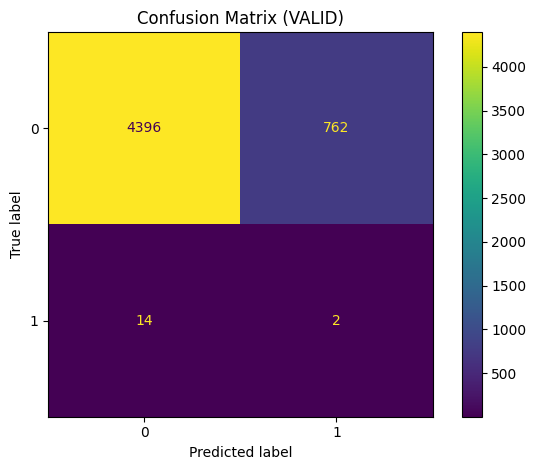


Classification report (VALID):
              precision    recall  f1-score   support

           0      0.997     0.852     0.919      5158
           1      0.003     0.125     0.005        16

    accuracy                          0.850      5174
   macro avg      0.500     0.489     0.462      5174
weighted avg      0.994     0.850     0.916      5174



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, fbeta_score,
    classification_report
)

threshold = 0.50  # start here; we will tune later

y_valid_hat = (p_valid >= threshold).astype(int)

cm = confusion_matrix(y_valid, y_valid_hat)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_valid, y_valid_hat)
bal_acc = balanced_accuracy_score(y_valid, y_valid_hat)
precision = precision_score(y_valid, y_valid_hat, zero_division=0)
recall = recall_score(y_valid, y_valid_hat, zero_division=0)
f1 = f1_score(y_valid, y_valid_hat, zero_division=0)
f2 = fbeta_score(y_valid, y_valid_hat, beta=2, zero_division=0)

specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

print("VALID RESULTS (threshold =", threshold, ")")
print("Confusion matrix [[TN, FP],[FN, TP]]:")
print(cm)

print("\nMetrics:")
print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(bal_acc, 4))
print("Precision (PPV):", round(precision, 4))
print("Recall (Sensitivity):", round(recall, 4))
print("F1:", round(f1, 4))
print("F2:", round(f2, 4))
print("Specificity (TNR):", round(specificity, 4))
print("FPR:", round(fpr, 4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(values_format="d")
plt.title("Confusion Matrix (VALID)")
plt.tight_layout()
plt.show()

print("\nClassification report (VALID):")
print(classification_report(y_valid, y_valid_hat, digits=3, zero_division=0))


3.7 Choose a decision threshold on VALID (recommended for rare stroke)

In [ ]:
thresholds = np.linspace(0.01, 0.50, 100)
f2_scores = []

for t in thresholds:
    yhat = (p_valid >= t).astype(int)
    f2_scores.append(fbeta_score(y_valid, yhat, beta=2, zero_division=0))

best_idx = int(np.argmax(f2_scores))
best_t = float(thresholds[best_idx])

print("Best threshold on VALID (max F2):", round(best_t, 3))
print("Best VALID F2:", round(float(f2_scores[best_idx]), 4))


Best threshold on VALID (max F2): 0.04
Best VALID F2: 0.0174


In [ ]:
threshold = best_t


Logistic Regression

LOGREG VALID RESULTS (threshold = 0.5 )
Confusion matrix [[TN, FP],[FN, TP]]:
[[3230 1928]
 [   5   11]]

Metrics:
Accuracy: 0.6264
Balanced Accuracy: 0.6569
Precision (PPV): 0.0057
Recall (Sensitivity): 0.6875
F1: 0.0113
F2: 0.0275
Specificity (TNR): 0.6262
FPR: 0.3738
AUROC: 0.6731
AUPRC: 0.006
VALID positives: 16 out of 5174


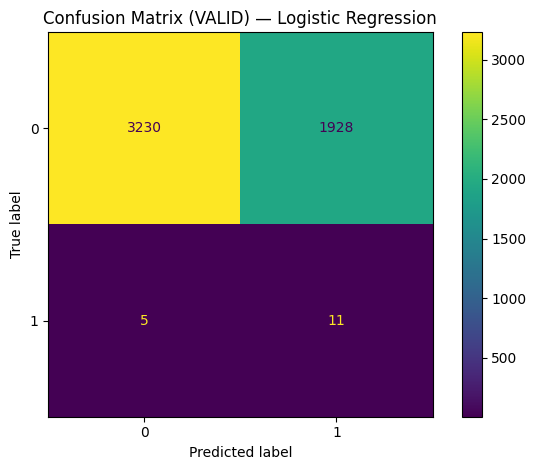

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score
)
import matplotlib.pyplot as plt

# ----------------------------
# Logistic Regression baseline
# ----------------------------
logreg = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",   # important for rare outcomes
    solver="lbfgs"
)

logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),   # your existing preprocess (log+impute+scale+onehot)
    ("model", logreg)
])

logreg_pipe.fit(X_train, y_train)

# ----------------------------
# VALID evaluation (threshold=0.50 baseline)
# ----------------------------
threshold = 0.50
p_valid = logreg_pipe.predict_proba(X_valid)[:, 1]
y_valid_hat = (p_valid >= threshold).astype(int)

cm = confusion_matrix(y_valid, y_valid_hat)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_valid, y_valid_hat)
bal_acc  = balanced_accuracy_score(y_valid, y_valid_hat)

precision = precision_score(y_valid, y_valid_hat, zero_division=0)
recall    = recall_score(y_valid, y_valid_hat, zero_division=0)
f1        = f1_score(y_valid, y_valid_hat, zero_division=0)
f2        = fbeta_score(y_valid, y_valid_hat, beta=2, zero_division=0)

specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
fpr         = fp / (fp + tn) if (fp + tn) > 0 else np.nan

auroc = roc_auc_score(y_valid, p_valid)
auprc = average_precision_score(y_valid, p_valid)

print("LOGREG VALID RESULTS (threshold =", threshold, ")")
print("Confusion matrix [[TN, FP],[FN, TP]]:")
print(cm)

print("\nMetrics:")
print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(bal_acc, 4))
print("Precision (PPV):", round(precision, 4))
print("Recall (Sensitivity):", round(recall, 4))
print("F1:", round(f1, 4))
print("F2:", round(f2, 4))
print("Specificity (TNR):", round(specificity, 4))
print("FPR:", round(fpr, 4))
print("AUROC:", round(auroc, 4))
print("AUPRC:", round(auprc, 4))
print("VALID positives:", int(y_valid.sum()), "out of", len(y_valid))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.title("Confusion Matrix (VALID) — Logistic Regression")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

p_valid = logreg_pipe.predict_proba(X_valid)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_valid, p_valid)
prec = precision[:-1]
rec  = recall[:-1]
thr  = thresholds

f2_scores = (5 * prec * rec) / (4 * prec + rec + 1e-12)

best_idx = np.nanargmax(f2_scores)
best_thr = thr[best_idx]

print("Best threshold (F2):", round(best_thr, 4))
print("Best VALID F2:", round(float(f2_scores[best_idx]), 4))
print("Precision:", round(float(prec[best_idx]), 4))
print("Recall:", round(float(rec[best_idx]), 4))


Best threshold (F2): 0.8033
Best VALID F2: 0.0407
Precision: 0.0169
Recall: 0.0625


In [ ]:
def evaluate_threshold(pipe, X, y, threshold, label=""):
    p = pipe.predict_proba(X)[:, 1]
    y_hat = (p >= threshold).astype(int)

    cm = confusion_matrix(y, y_hat)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{label} — threshold = {threshold}")
    print(cm)
    print("Recall:", round(tp / (tp + fn), 4))
    print("Precision:", round(tp / (tp + fp), 4))
    print("Balanced Acc:", round(balanced_accuracy_score(y, y_hat), 4))
    print("AUROC:", round(roc_auc_score(y, p), 4))
    print("AUPRC:", round(average_precision_score(y, p), 4))

# TEST evaluation
evaluate_threshold(logreg_pipe, X_test, y_test, 0.50, "TEST (baseline)")
evaluate_threshold(logreg_pipe, X_test, y_test, 0.80, "TEST (high threshold)")



TEST (baseline) — threshold = 0.5
[[3196 1962]
 [   6   10]]
Recall: 0.625
Precision: 0.0051
Balanced Acc: 0.6223
AUROC: 0.7368
AUPRC: 0.0188

TEST (high threshold) — threshold = 0.8
[[5078   80]
 [  14    2]]
Recall: 0.125
Precision: 0.0244
Balanced Acc: 0.5547
AUROC: 0.7368
AUPRC: 0.0188


Random Forest

RF VALID RESULTS (threshold = 0.5 )
Confusion matrix [[TN, FP],[FN, TP]]:
[[4756  402]
 [  16    0]]

Metrics:
Accuracy: 0.9192
Balanced Accuracy: 0.461
Precision (PPV): 0.0
Recall (Sensitivity): 0.0
F1: 0.0
F2: 0.0
Specificity (TNR): 0.9221
FPR: 0.0779
AUROC: 0.5348
AUPRC: 0.0033
VALID positives: 16 out of 5174


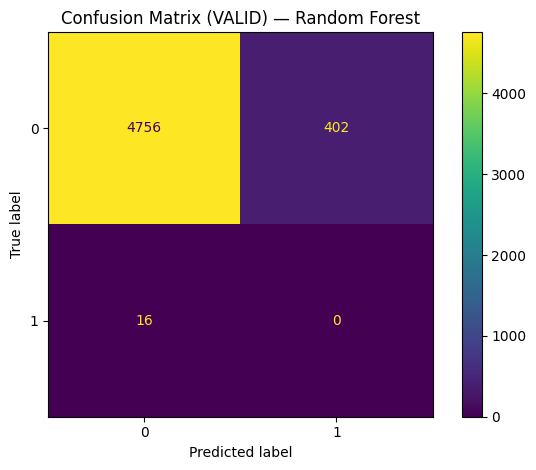


Classification report (VALID):
              precision    recall  f1-score   support

           0      0.997     0.922     0.958      5158
           1      0.000     0.000     0.000        16

    accuracy                          0.919      5174
   macro avg      0.498     0.461     0.479      5174
weighted avg      0.994     0.919     0.955      5174



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score
)

# =========================
# RANDOM FOREST (BASELINE)
# =========================
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",  # IMPORTANT for imbalance
    max_features="sqrt"
)

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),  # your leakage-safe preprocess
    ("model", rf)
])

rf_pipe.fit(X_train, y_train)

# =========================
# VALIDATION EVALUATION
# =========================
threshold = 0.50

p_valid = rf_pipe.predict_proba(X_valid)[:, 1]
y_valid_hat = (p_valid >= threshold).astype(int)

cm = confusion_matrix(y_valid, y_valid_hat)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_valid, y_valid_hat)
bal_acc = balanced_accuracy_score(y_valid, y_valid_hat)

precision = precision_score(y_valid, y_valid_hat, zero_division=0)
recall = recall_score(y_valid, y_valid_hat, zero_division=0)
f1 = f1_score(y_valid, y_valid_hat, zero_division=0)
f2 = fbeta_score(y_valid, y_valid_hat, beta=2, zero_division=0)

specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

auroc = roc_auc_score(y_valid, p_valid)
auprc = average_precision_score(y_valid, p_valid)

print("RF VALID RESULTS (threshold =", threshold, ")")
print("Confusion matrix [[TN, FP],[FN, TP]]:")
print(cm)

print("\nMetrics:")
print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(bal_acc, 4))
print("Precision (PPV):", round(precision, 4))
print("Recall (Sensitivity):", round(recall, 4))
print("F1:", round(f1, 4))
print("F2:", round(f2, 4))
print("Specificity (TNR):", round(specificity, 4))
print("FPR:", round(fpr, 4))
print("AUROC:", round(auroc, 4))
print("AUPRC:", round(auprc, 4))
print("VALID positives:", int((y_valid == 1).sum()), "out of", len(y_valid))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.title("Confusion Matrix (VALID) — Random Forest")
plt.tight_layout()
plt.show()

print("\nClassification report (VALID):")
print(classification_report(y_valid, y_valid_hat, digits=3, zero_division=0))


In [ ]:
for thr in [0.5, 0.2, 0.1, 0.05, 0.02]:
    yhat = (p_valid >= thr).astype(int)
    f2 = fbeta_score(y_valid, yhat, beta=2, zero_division=0)
    rec = recall_score(y_valid, yhat, zero_division=0)
    prec = precision_score(y_valid, yhat, zero_division=0)
    print(f"thr={thr:.2f} | F2={f2:.4f} | recall={rec:.3f} | precision={prec:.4f} | predicted_pos={yhat.sum()}")


thr=0.50 | F2=0.0000 | recall=0.000 | precision=0.0000 | predicted_pos=402
thr=0.20 | F2=0.0000 | recall=0.000 | precision=0.0000 | predicted_pos=402
thr=0.10 | F2=0.0000 | recall=0.000 | precision=0.0000 | predicted_pos=406
thr=0.05 | F2=0.0000 | recall=0.000 | precision=0.0000 | predicted_pos=421
thr=0.02 | F2=0.0000 | recall=0.000 | precision=0.0000 | predicted_pos=493


Fitting 5 folds for each of 28 candidates, totalling 140 fits

✅ Best LR params: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1'}
✅ Best CV AUPRC: 0.010007

VALID (LogReg tuned) RESULTS (threshold = 0.5)
Confusion matrix [[TN, FP],[FN, TP]]:
[[5158    0]
 [  16    0]]

Metrics:
Accuracy: 0.9969
Balanced Accuracy: 0.5
Precision (PPV): 0.0
Recall (Sensitivity): 0.0
F1: 0.0
F2: 0.0
Specificity (TNR): 1.0
FPR: 0.0
AUROC: 0.8105
AUPRC: 0.011308


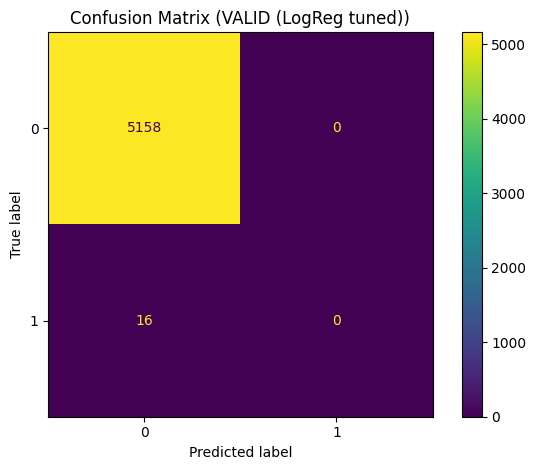


Classification report:
              precision    recall  f1-score   support

           0      0.997     1.000     0.998      5158
           1      0.000     0.000     0.000        16

    accuracy                          0.997      5174
   macro avg      0.498     0.500     0.499      5174
weighted avg      0.994     0.997     0.995      5174


✅ Best threshold on VALID (max F2): 0.0063
✅ Best VALID F2: 0.069444
Precision: 0.017857
Recall: 0.25


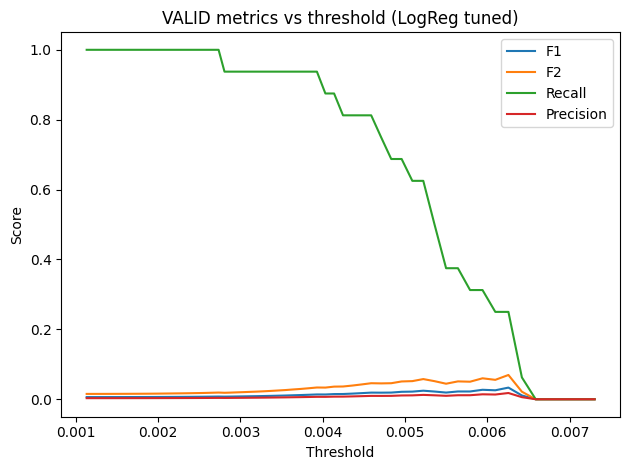


VALID (LogReg tuned, best F2 thr) RESULTS (threshold = 0.006255813311278786)
Confusion matrix [[TN, FP],[FN, TP]]:
[[4938  220]
 [  12    4]]

Metrics:
Accuracy: 0.9552
Balanced Accuracy: 0.6037
Precision (PPV): 0.0179
Recall (Sensitivity): 0.25
F1: 0.0333
F2: 0.0694
Specificity (TNR): 0.9573
FPR: 0.0427
AUROC: 0.8105
AUPRC: 0.011308


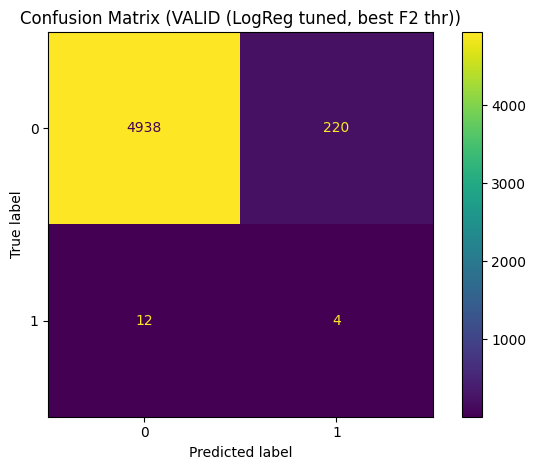


Classification report:
              precision    recall  f1-score   support

           0      0.998     0.957     0.977      5158
           1      0.018     0.250     0.033        16

    accuracy                          0.955      5174
   macro avg      0.508     0.604     0.505      5174
weighted avg      0.995     0.955     0.974      5174


TEST (LogReg tuned) RESULTS (threshold = 0.006255813311278786)
Confusion matrix [[TN, FP],[FN, TP]]:
[[4932  226]
 [  12    4]]

Metrics:
Accuracy: 0.954
Balanced Accuracy: 0.6031
Precision (PPV): 0.0174
Recall (Sensitivity): 0.25
F1: 0.0325
F2: 0.068
Specificity (TNR): 0.9562
FPR: 0.0438
AUROC: 0.7715
AUPRC: 0.024608


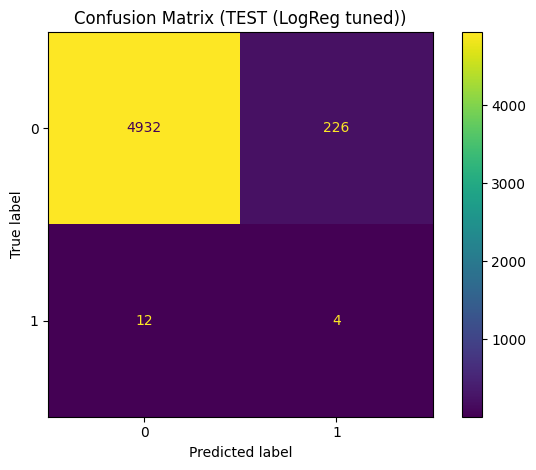


Classification report:
              precision    recall  f1-score   support

           0      0.998     0.956     0.976      5158
           1      0.017     0.250     0.033        16

    accuracy                          0.954      5174
   macro avg      0.507     0.603     0.504      5174
weighted avg      0.995     0.954     0.974      5174


Top 20 features increasing odds (highest OR):


,feature,coef,odds_ratio
0,num__Age_at_Exam,0.345961,1.413347
1,num__HTN_FW,0.000000,1.000000
2,num__AFib_FW,0.000000,1.000000
3,num__CAD_FW,0.000000,1.000000
4,num__sBP_Mean_FW,0.000000,1.000000
5,num__A1c_Mean_FW,0.000000,1.000000
6,num__LDL_Mean_FW,0.000000,1.000000
7,num__TG_Mean_FW,0.000000,1.000000
8,num__FBS_Mean_FW,0.000000,1.000000
9,num__BMI_Last_FW,0.000000,1.000000



Top 20 features decreasing odds (lowest OR):


,feature,coef,odds_ratio
1,num__HTN_FW,0.000000,1.000000
2,num__AFib_FW,0.000000,1.000000
3,num__CAD_FW,0.000000,1.000000
4,num__sBP_Mean_FW,0.000000,1.000000
6,num__LDL_Mean_FW,0.000000,1.000000
5,num__A1c_Mean_FW,0.000000,1.000000
7,num__TG_Mean_FW,0.000000,1.000000
8,num__FBS_Mean_FW,0.000000,1.000000
12,num__missingindicator_A1c_Mean_FW,0.000000,1.000000
9,num__BMI_Last_FW,0.000000,1.000000


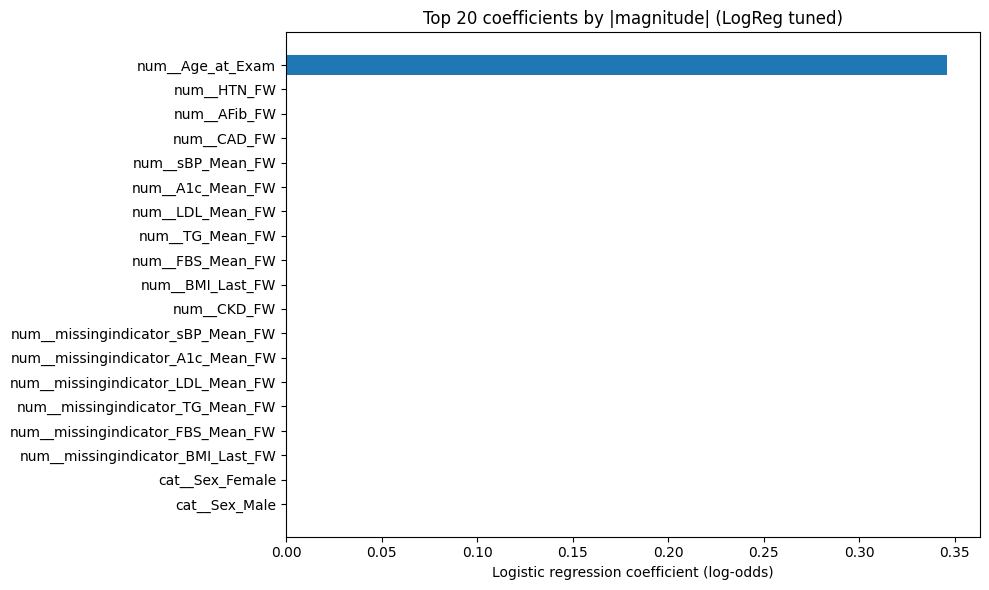

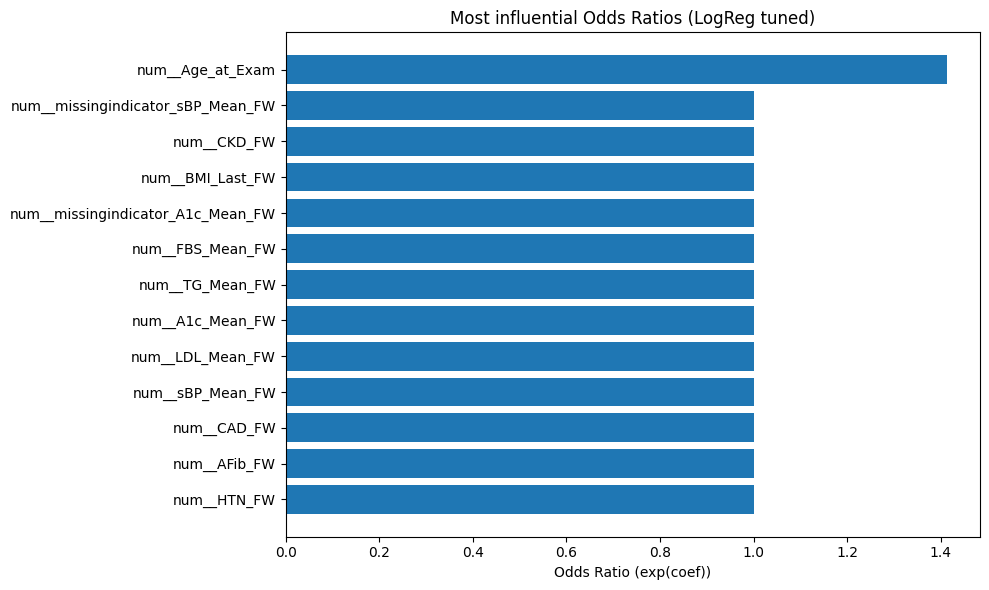

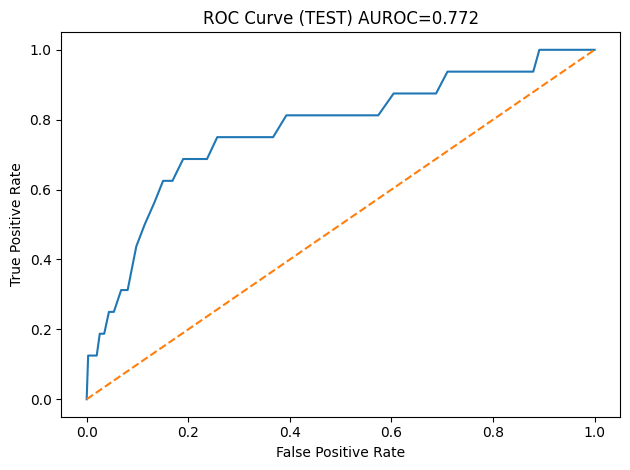

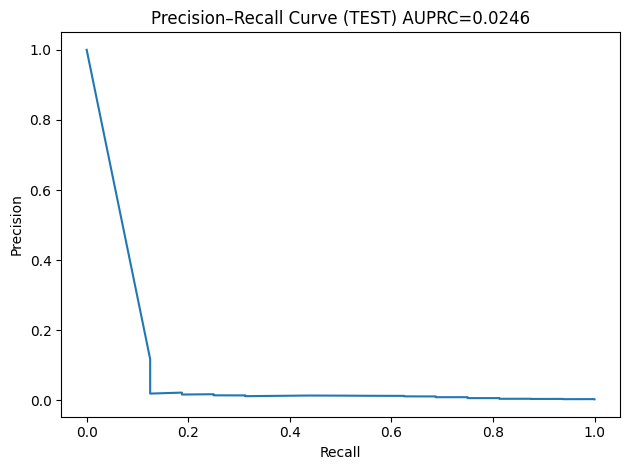

In [ ]:
# =========================
# Logistic Regression — Tuning + Odds Ratios + Plots (Leakage-safe)
# Assumes you already have: X_train, y_train, X_valid, y_valid, X_test, y_test
# and your "preprocess" ColumnTransformer from earlier (with log+impute+scale+onehot)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)

RANDOM_STATE = 42

# -------------------------
# 1) Define leakage-safe LR pipeline (preprocess fit only on TRAIN folds)
# -------------------------
logreg = LogisticRegression(
    solver="liblinear",   # supports l1 + l2
    max_iter=5000,
    random_state=RANDOM_STATE
)

pipe_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])

# -------------------------
# 2) GridSearchCV (TRAIN only) — tune only high-impact LR params
# -------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# For very imbalanced outcomes, scoring="average_precision" is usually best
param_grid = [
    {
        "model__penalty": ["l2"],
        "model__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__penalty": ["l1"],
        "model__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
        "model__class_weight": [None, "balanced"]
    }
]

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid,
    scoring="average_precision",  # AUPRC
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_lr.fit(X_train, y_train)

best_pipe_lr = grid_lr.best_estimator_
print("\n✅ Best LR params:", grid_lr.best_params_)
print("✅ Best CV AUPRC:", round(float(grid_lr.best_score_), 6))


# -------------------------
# 3) VALID evaluation helper (thresholded + threshold-free)
# -------------------------
def eval_at_threshold(name, y_true, p, threshold=0.5, plot_cm=True):
    y_hat = (p >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_hat)
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_hat)
    bal_acc = balanced_accuracy_score(y_true, y_hat)
    precision = precision_score(y_true, y_hat, zero_division=0)
    recall = recall_score(y_true, y_hat, zero_division=0)
    f1 = f1_score(y_true, y_hat, zero_division=0)
    f2 = fbeta_score(y_true, y_hat, beta=2, zero_division=0)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

    auroc = roc_auc_score(y_true, p)
    auprc = average_precision_score(y_true, p)

    print(f"\n{name} RESULTS (threshold = {threshold})")
    print("Confusion matrix [[TN, FP],[FN, TP]]:")
    print(cm)
    print("\nMetrics:")
    print("Accuracy:", round(accuracy, 4))
    print("Balanced Accuracy:", round(bal_acc, 4))
    print("Precision (PPV):", round(precision, 4))
    print("Recall (Sensitivity):", round(recall, 4))
    print("F1:", round(f1, 4))
    print("F2:", round(f2, 4))
    print("Specificity (TNR):", round(specificity, 4))
    print("FPR:", round(fpr, 4))
    print("AUROC:", round(auroc, 4))
    print("AUPRC:", round(auprc, 6))

    if plot_cm:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        disp.plot()
        plt.title(f"Confusion Matrix ({name})")
        plt.tight_layout()
        plt.show()

    print("\nClassification report:")
    print(classification_report(y_true, y_hat, digits=3, zero_division=0))

    return {
        "cm": cm,
        "threshold": threshold,
        "accuracy": accuracy,
        "balanced_accuracy": bal_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
        "specificity": specificity,
        "fpr": fpr,
        "auroc": auroc,
        "auprc": auprc
    }

# VALID probs
p_valid = best_pipe_lr.predict_proba(X_valid)[:, 1]

# Baseline threshold=0.5
valid_metrics_05 = eval_at_threshold("VALID (LogReg tuned)", y_valid, p_valid, threshold=0.50)


# -------------------------
# 4) Choose best threshold on VALID (maximize F2) + plot metrics vs threshold
# -------------------------
precision, recall, thresholds = precision_recall_curve(y_valid, p_valid)

prec = precision[:-1]
rec = recall[:-1]
thr = thresholds

f1_scores = (2 * prec * rec) / (prec + rec + 1e-12)
f2_scores = (5 * prec * rec) / (4 * prec + rec + 1e-12)

best_idx = int(np.nanargmax(f2_scores))
best_thr_f2 = float(thr[best_idx])

print("\n✅ Best threshold on VALID (max F2):", round(best_thr_f2, 4))
print("✅ Best VALID F2:", round(float(f2_scores[best_idx]), 6))
print("Precision:", round(float(prec[best_idx]), 6))
print("Recall:", round(float(rec[best_idx]), 6))

# Plot threshold sensitivity
plt.figure()
plt.plot(thr, f1_scores, label="F1")
plt.plot(thr, f2_scores, label="F2")
plt.plot(thr, rec, label="Recall")
plt.plot(thr, prec, label="Precision")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("VALID metrics vs threshold (LogReg tuned)")
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate VALID at best threshold
valid_metrics_best = eval_at_threshold("VALID (LogReg tuned, best F2 thr)", y_valid, p_valid, threshold=best_thr_f2)


# -------------------------
# 5) FINAL TEST evaluation (run once you are done choosing threshold/model)
# -------------------------
p_test = best_pipe_lr.predict_proba(X_test)[:, 1]

# Choose ONE threshold strategy:
# threshold = 0.50
threshold = best_thr_f2

test_metrics = eval_at_threshold("TEST (LogReg tuned)", y_test, p_test, threshold=threshold)


# -------------------------
# 6) Odds Ratios + Coefficient table (interpretability)
#    IMPORTANT: use preprocess feature names after fitting best_pipe_lr
# -------------------------
feature_names = best_pipe_lr.named_steps["preprocess"].get_feature_names_out()
coef = best_pipe_lr.named_steps["model"].coef_.ravel()

or_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "odds_ratio": np.exp(coef)
}).sort_values("odds_ratio", ascending=False)

print("\nTop 20 features increasing odds (highest OR):")
display(or_df.head(20))

print("\nTop 20 features decreasing odds (lowest OR):")
display(or_df.tail(20).sort_values("odds_ratio", ascending=True))


# -------------------------
# 7) Plot: Top coefficients by absolute magnitude (most influential)
# -------------------------
top_k = 20
or_df_abs = or_df.assign(abs_coef=np.abs(or_df["coef"])).sort_values("abs_coef", ascending=False).head(top_k)

plt.figure(figsize=(10, 6))
plt.barh(or_df_abs["feature"][::-1], or_df_abs["coef"][::-1])
plt.xlabel("Logistic regression coefficient (log-odds)")
plt.title(f"Top {top_k} coefficients by |magnitude| (LogReg tuned)")
plt.tight_layout()
plt.show()


# -------------------------
# 8) Plot: Top odds ratios (increase risk) and bottom odds ratios (decrease risk)
# -------------------------
top_pos = 12
top_neg = 12

top_increase = or_df.sort_values("odds_ratio", ascending=False).head(top_pos)
top_decrease = or_df.sort_values("odds_ratio", ascending=True).head(top_neg)

plot_df = pd.concat([top_decrease, top_increase], axis=0)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["odds_ratio"])
plt.xlabel("Odds Ratio (exp(coef))")
plt.title("Most influential Odds Ratios (LogReg tuned)")
plt.tight_layout()
plt.show()


# -------------------------
# 9) Optional: ROC + PR curves on TEST
# -------------------------
# ROC
fpr, tpr, _ = roc_curve(y_test, p_test)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (TEST) AUROC={roc_auc_score(y_test, p_test):.3f}")
plt.tight_layout()
plt.show()

# PR
prec_curve, rec_curve, _ = precision_recall_curve(y_test, p_test)
plt.figure()
plt.plot(rec_curve, prec_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (TEST) AUPRC={average_precision_score(y_test, p_test):.4f}")
plt.tight_layout()
plt.show()


A) GridSearchCV for Logistic Regression (AUPRC scoring)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import average_precision_score

# ----------------------------
# 1) Logistic Regression pipe
# ----------------------------
logreg = LogisticRegression(
    max_iter=5000,
    solver="saga",          # supports l1 + l2
    random_state=42
)

pipe_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])

# ----------------------------
# 2) CV + Grid
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "model__penalty": ["l1", "l2"],
    "model__C": [0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"],
}

grid = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid,
    scoring="average_precision",   # AUPRC
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_pipe = grid.best_estimator_
print("✅ Best LR params:", grid.best_params_)
print("✅ Best CV AUPRC:", round(float(grid.best_score_), 6))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
✅ Best LR params: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l1'}
✅ Best CV AUPRC: 0.010863


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


B) Evaluate o

VALID (LogReg tuned) (threshold = 0.5)
Confusion matrix [[TN, FP],[FN, TP]]:
[[1706 3452]
 [   9    7]]

Metrics:
Accuracy: 0.3311
Balanced Accuracy: 0.3841
Precision (PPV): 0.002
Recall (Sensitivity): 0.4375
F1: 0.004
F2: 0.0099
Specificity (TNR): 0.3307
FPR: 0.6693
AUROC: 0.3591
AUPRC: 0.002441
Positives: 16 out of 5174


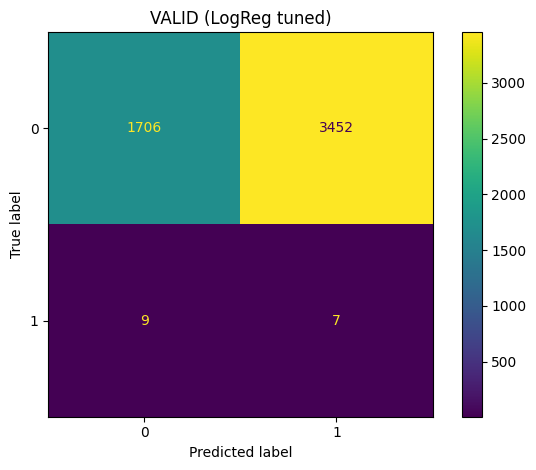


Classification report:
              precision    recall  f1-score   support

           0      0.995     0.331     0.496      5158
           1      0.002     0.438     0.004        16

    accuracy                          0.331      5174
   macro avg      0.498     0.384     0.250      5174
weighted avg      0.992     0.331     0.495      5174



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score,
    classification_report
)

def eval_binary(pipe, X, y, threshold=0.5, title=""):
    p = pipe.predict_proba(X)[:, 1]
    y_hat = (p >= threshold).astype(int)

    cm = confusion_matrix(y, y_hat)
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y, y_hat)
    bal_acc = balanced_accuracy_score(y, y_hat)
    precision = precision_score(y, y_hat, zero_division=0)
    recall = recall_score(y, y_hat, zero_division=0)
    f1 = f1_score(y, y_hat, zero_division=0)
    f2 = fbeta_score(y, y_hat, beta=2, zero_division=0)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

    auroc = roc_auc_score(y, p)
    auprc = average_precision_score(y, p)

    print(f"{title} (threshold = {threshold})")
    print("Confusion matrix [[TN, FP],[FN, TP]]:")
    print(cm)

    print("\nMetrics:")
    print("Accuracy:", round(accuracy, 4))
    print("Balanced Accuracy:", round(bal_acc, 4))
    print("Precision (PPV):", round(precision, 4))
    print("Recall (Sensitivity):", round(recall, 4))
    print("F1:", round(f1, 4))
    print("F2:", round(f2, 4))
    print("Specificity (TNR):", round(specificity, 4))
    print("FPR:", round(fpr, 4))
    print("AUROC:", round(auroc, 4))
    print("AUPRC:", round(auprc, 6))
    print(f"Positives: {int(y.sum())} out of {len(y)}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot()
    plt.title(title)
    plt.tight_layout()
    plt.show()

    print("\nClassification report:")
    print(classification_report(y, y_hat, digits=3, zero_division=0))

    return p  # return probabilities for thresholding later


# VALID baseline (0.5)
p_valid = eval_binary(best_pipe, X_valid, y_valid, threshold=0.5, title="VALID (LogReg tuned)")


Choose best threshold on VALID (maximize F2)

✅ Best threshold on VALID (max F2): 1.8709885869235692e-06
✅ Best VALID F2: 0.015683199372656536
Precision: 0.0031764939448084176
Recall: 1.0


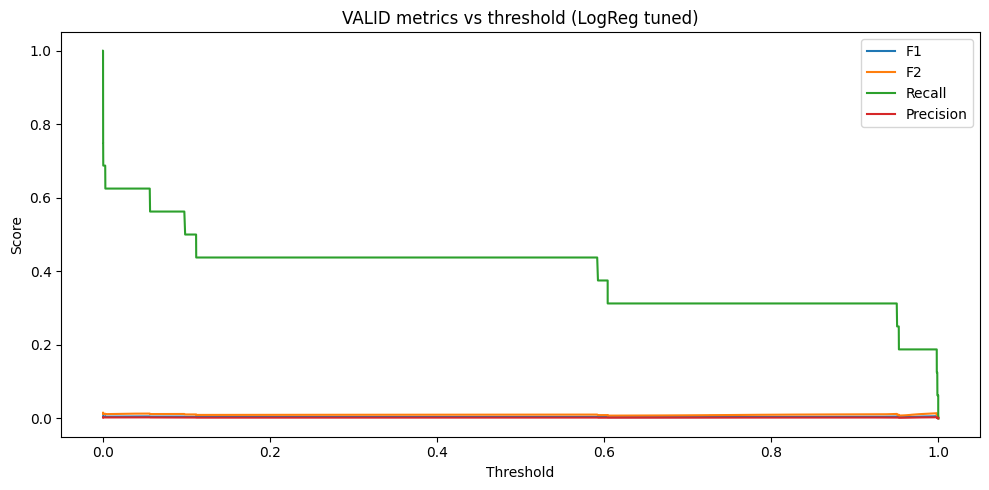

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_valid, p_valid)

prec = precision[:-1]
rec = recall[:-1]
thr = thresholds

f2_scores = (5 * prec * rec) / (4 * prec + rec + 1e-12)

best_idx = int(np.nanargmax(f2_scores))
best_threshold_f2 = float(thr[best_idx])

print(" Best threshold on VALID (max F2):", best_threshold_f2)
print(" Best VALID F2:", float(f2_scores[best_idx]))
print("Precision:", float(prec[best_idx]))
print("Recall:", float(rec[best_idx]))

f1_scores = (2 * prec * rec) / (prec + rec + 1e-12)

plt.figure(figsize=(10,5))
plt.plot(thr, f1_scores, label="F1")
plt.plot(thr, f2_scores, label="F2")
plt.plot(thr, rec, label="Recall")
plt.plot(thr, prec, label="Precision")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("VALID metrics vs threshold (LogReg tuned)")
plt.legend()
plt.tight_layout()
plt.show()


Final TEST evaluation

TEST (LogReg tuned, best F2 threshold) (threshold = 1.8709885869235692e-06)
Confusion matrix [[TN, FP],[FN, TP]]:
[[ 137 5021]
 [   0   16]]

Metrics:
Accuracy: 0.0296
Balanced Accuracy: 0.5133
Precision (PPV): 0.0032
Recall (Sensitivity): 1.0
F1: 0.0063
F2: 0.0157
Specificity (TNR): 0.0266
FPR: 0.9734
AUROC: 0.5621
AUPRC: 0.004285
Positives: 16 out of 5174


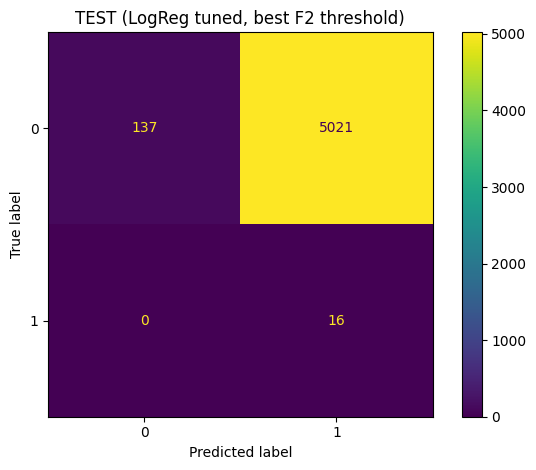


Classification report:
              precision    recall  f1-score   support

           0      1.000     0.027     0.052      5158
           1      0.003     1.000     0.006        16

    accuracy                          0.030      5174
   macro avg      0.502     0.513     0.029      5174
weighted avg      0.997     0.030     0.052      5174



In [ ]:
_ = eval_binary(
    best_pipe,
    X_test, y_test,
    threshold=best_threshold_f2,
    title="TEST (LogReg tuned, best F2 threshold)"
)


Odds ratios table + coefficient / OR plots

In [ ]:
# Get feature names after preprocessing
feature_names = best_pipe.named_steps["preprocess"].get_feature_names_out()

# Get LR coefficients
lr_model = best_pipe.named_steps["model"]
coef = lr_model.coef_.ravel()

or_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "odds_ratio": np.exp(coef)
}).sort_values("odds_ratio", ascending=False)

display(or_df.head(20))         # highest OR
display(or_df.sort_values("odds_ratio").head(20))  # lowest OR


,feature,coef,odds_ratio
9,num__BMI_Last_FW,5.355216,211.709750
1,num__HTN_FW,4.938494,139.559970
11,num__missingindicator_sBP_Mean_FW,3.445031,31.344260
18,cat__Sex_Male,2.004871,7.425138
14,num__missingindicator_TG_Mean_FW,1.130647,3.097661
15,num__missingindicator_FBS_Mean_FW,0.816062,2.261577
13,num__missingindicator_LDL_Mean_FW,0.658156,1.931229
4,num__sBP_Mean_FW,0.051889,1.053258
8,num__FBS_Mean_FW,0.001773,1.001774
3,num__CAD_FW,0.000000,1.000000


,feature,coef,odds_ratio
12,num__missingindicator_A1c_Mean_FW,-2.049090,0.128852
7,num__TG_Mean_FW,-1.647579,0.192515
16,num__missingindicator_BMI_Last_FW,-1.466408,0.230753
6,num__LDL_Mean_FW,-0.536730,0.584657
0,num__Age_at_Exam,-0.347408,0.706517
17,cat__Sex_Female,-0.341096,0.710991
5,num__A1c_Mean_FW,-0.124365,0.883057
10,num__CKD_FW,0.000000,1.000000
2,num__AFib_FW,0.000000,1.000000
3,num__CAD_FW,0.000000,1.000000


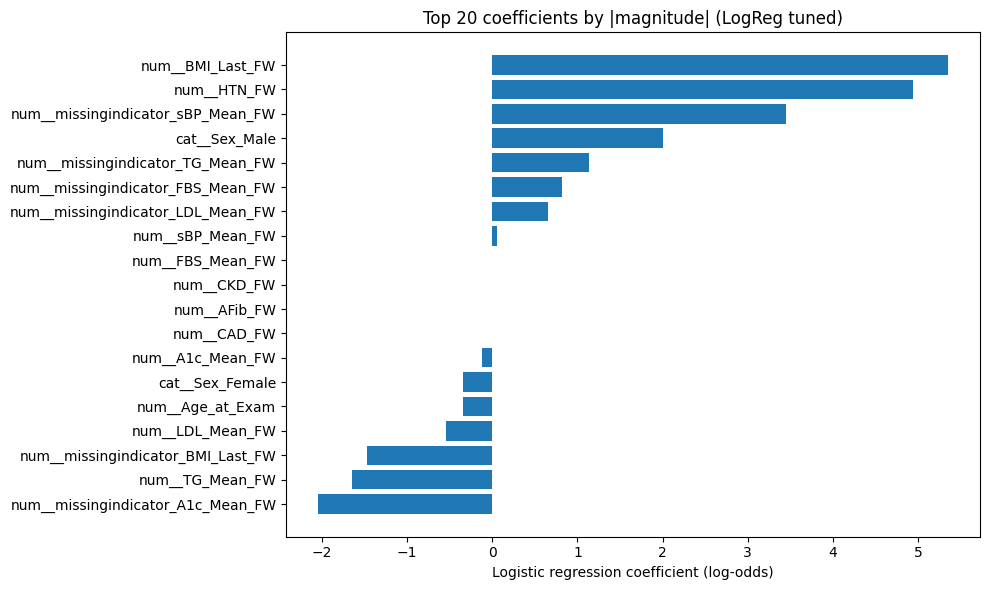

In [ ]:
top_k = 20
or_df_mag = or_df.copy()
or_df_mag["abs_coef"] = np.abs(or_df_mag["coef"])
top = or_df_mag.sort_values("abs_coef", ascending=False).head(top_k).sort_values("coef")

plt.figure(figsize=(10,6))
plt.barh(top["feature"], top["coef"])
plt.xlabel("Logistic regression coefficient (log-odds)")
plt.title(f"Top {top_k} coefficients by |magnitude| (LogReg tuned)")
plt.tight_layout()
plt.show()


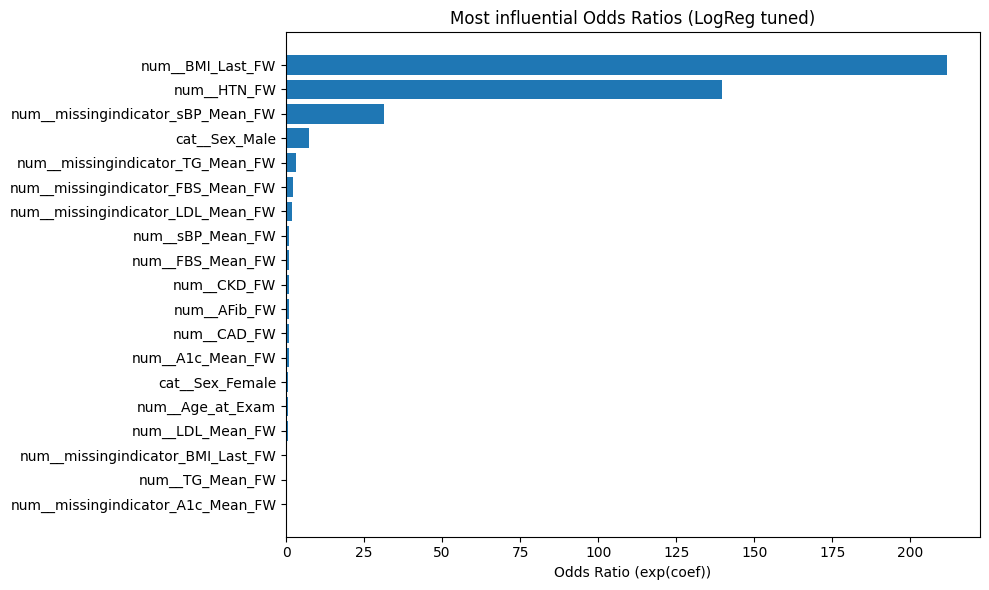

In [ ]:
top_or = or_df_mag.sort_values("abs_coef", ascending=False).head(top_k).sort_values("odds_ratio")

plt.figure(figsize=(10,6))
plt.barh(top_or["feature"], top_or["odds_ratio"])
plt.xlabel("Odds Ratio (exp(coef))")
plt.title(f"Most influential Odds Ratios (LogReg tuned)")
plt.tight_layout()
plt.show()



95% CI for ORs (bootstrap, leakage-safe)

In [ ]:
from sklearn.utils import resample

def bootstrap_or_ci(best_pipe, X_train, y_train, n_boot=200, random_state=42):
    rng = np.random.RandomState(random_state)
    feature_names = best_pipe.named_steps["preprocess"].get_feature_names_out()

    coefs = []
    n = len(X_train)

    for b in range(n_boot):
        idx = rng.randint(0, n, size=n)
        Xb = X_train.iloc[idx]
        yb = y_train.iloc[idx]

        # refit on bootstrap sample
        best_pipe.fit(Xb, yb)
        coef_b = best_pipe.named_steps["model"].coef_.ravel()
        coefs.append(coef_b)

    coefs = np.vstack(coefs)
    coef_lo = np.percentile(coefs, 2.5, axis=0)
    coef_hi = np.percentile(coefs, 97.5, axis=0)

    ci_df = pd.DataFrame({
        "feature": feature_names,
        "coef": best_pipe.named_steps["model"].coef_.ravel(),
        "OR": np.exp(best_pipe.named_steps["model"].coef_.ravel()),
        "OR_2.5%": np.exp(coef_lo),
        "OR_97.5%": np.exp(coef_hi),
    }).sort_values("OR", ascending=False)

    return ci_df

ci_df = bootstrap_or_ci(best_pipe, X_train, y_train, n_boot=200)
display(ci_df.head(25))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

,feature,coef,OR,OR_2.5%,OR_97.5%
0,num__Age_at_Exam,6.133541,461.065697,0.450743,655.017177
15,num__missingindicator_FBS_Mean_FW,3.098524,22.165208,0.056218,42.183709
11,num__missingindicator_sBP_Mean_FW,1.176550,3.243165,0.376335,1023.382350
17,cat__Sex_Female,0.334870,1.397759,0.070805,9.259164
7,num__TG_Mean_FW,0.131745,1.140818,0.015504,49.433653
4,num__sBP_Mean_FW,0.097311,1.102204,0.006480,199.521995
9,num__BMI_Last_FW,0.006924,1.006948,0.034303,1618.442734
10,num__CKD_FW,0.000000,1.000000,1.000000,1.000000
2,num__AFib_FW,0.000000,1.000000,1.000000,1.000000
3,num__CAD_FW,0.000000,1.000000,1.000000,1.000000
